# Material Perturbation Models

Tidy3D provides a collection of classes for defining spatially dependent dispersive (`CustomPoleResidue`, `CustomLorentz`, `CustomSellmeier`, `CustomDrude`, `CustomDebye`) and non-dispersive materials (`CustomMedium`). Among many applications, this also allows to investigate the influence of spatially dependent heat and charge fields on the performane of optic devices. To make such studies even more effortless, one can use the closely related family of classes with prefix `Perturbation` (`PerturbationMedium`, `PerturbationPoleResidue`, `PerturbationLorentz`, ...) defining materials with specific responses to heat and charge data. They are designed to eliminate the need to define Custom-type materials by hand. Instead, one simply uses such perturbation materials while constructing their Tidy3D simulation, and once it is finished, function `Simulation.apply_perturations(temperature, electron_density, hole_density)` conveniently converts provided spatially varying `temperature`, `electron_density`, and/or `hole_density` fields into spatially perturbed `Custom`-type materials. In this tutorial we provide a basic demonstration of this functionality.

In Tidy3D heat and charge perturbations of material models are defined through perturbations of the parameters constituting each model. For example, `permittivity` and `conductivity` for class `Medium`, `eps_inf` and `poles` for class `PoleResidue`, etc. Perturbations to each parameters are specified using class `ParameterPerturbation`, which contains two fields `heat` and `charge`. Acceptable types for field `heat` are `LinearHeatPerturbation` and `CustomHeatPerturbation`, while for field `charge` those are `LinearChargePerturbation` and `CustomChargePerturbation`. 

`LinearHeatPerturbation` and `LinearChargePerturbation` are simple linear models of parameter perturbations described by equations 
$$ \Delta X = \text{coeff} \times (\text{temperature} - \text{temperature\_ref})$$
and
$$ \Delta X = \text{electron\_coeff} \times (\text{electron\_density} - \text{electron\_ref}) + \text{hole\_coeff} \times (\text{hole\_density} - \text{hole\_ref})$$
Thus, for the former one one must provide reference temperature `temperature_ref` and thermo-optic coefficient value `coeff`. Similarly, in case of a linear charge perturbation one provides reference electron and hole densities, `electron_ref` and `hole_ref`, and two corresponding linear coefficients, `electron_coeff` and `hole_coeff`.

Classes `CustomHeatPerturbation` and `CustomChargePerturbation` specify parameter perturbations in the form of look-up tables defined by classes `HeatDataArray` (1D array vs temperature) and `ChargeDataArray` (2D array vs electron and hole densities).

All basic heat and charge perturbation models also have an optional fields `temperature_range`, `electron_range`, and `hole_range` which describe ranges of temperature, electron density, and hole density in which provided perturbation approximation are provided. These are used to, first, verify that in the provided ranges underlying pertubed parameters do not go out of physically valid bounds, and, second, to warn user if provided `temperature`, `electron_density`, and/or `hole_density` data contain values outside of those ranges.

Let us demonstrate how this functionality can be used.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

import tidy3d as td
from tidy3d import web

## Perturbations of non-dispersive materials

### Creation of material with perturbation information

We start this tutorial with examples involving perturbations to non-dispersive materials, that is, defined by `PerturbationMedium` class. Specifically, we consider Si at 300 K in the vicinity of 1.55 $\mu$m wavelength. Thus, we assume this material to have refractive index of $n \approx 3.475$ and zero loss $k = 0$. 

In [19]:
wvl_um = 1.55
freq0 = td.C_0 / wvl_um

si = td.material_library['cSi']['Li1993_293K']
n_si, k_si = si.nk_model(frequency=td.C_0/np.array(wvl_um))

# convert to permittivity and conductivity
permittivity_si, conductivity_si = td.Medium.nk_to_eps_sigma(n=n_si, k=k_si, freq=freq0)

The thermal dependence of the refractive index is assumed to be linear with the thermo-optic coefficient $\frac{dn}{dT} = 1.8\times 10^{-4}$ K$^{-1}$. Note that the corresponding `Medium` parameter is `permittivity`, thus, one needs to convert $\frac{dn}{dT}$ to $\frac{d \varepsilon}{dT} = \frac{d(n^2)}{dT} = 2 n \frac{dn}{dT}$

In [20]:
dndT_si = 1.8e-4
depsdT_si = 2 * n_si * dndT_si
permittivity_si_heat = td.LinearHeatPerturbation(temperature_ref=300, coeff=depsdT_si)

The just created perturbation model can be visualized.

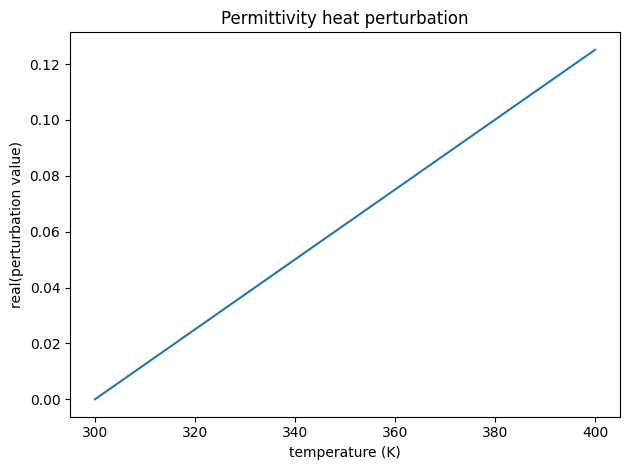

In [21]:
temp_plot_values = np.linspace(300, 400, 20)
ax = permittivity_si_heat.plot(temp_plot_values)
ax.set_title("Permittivity heat perturbation")
plt.show()

For the dependence of the refractive index on free carrier concentration we use data from [], that states that changes in $n$ and $k$ or Si can be described by formulas
$$ - \Delta n = \frac{dn}{dN_e}(\lambda) (\Delta N_e)^{\alpha(\lambda)} + \frac{dn}{dN_h}(\lambda) (\Delta N_h)^{\beta(\lambda)}$$
$$ \Delta \left( \frac{4 \pi k}{\lambda} \right) = \frac{dk}{dN_e}(\lambda) (\Delta N_e)^{\gamma(\lambda)} + \frac{dk}{dN_h}(\lambda) (\Delta N_h)^{\delta(\lambda)}$$
where $\Delta N_e$ and $\Delta N_h$ are electron and hole densities, and parameters have the following values in the range of wavelengths $[1.3; 2.0]$ $\mu$m:

| $\lambda$ | $\frac{dn}{dN_e}$ | $\alpha$ | $\frac{dn}{dN_h}$ | $\beta$ | $\frac{dk}{dN_e}$ | $\gamma$ | $\frac{dk}{dN_h}$ | $\delta$ |
| --------- | ----------------- | ------- | ------------------ | ------- | ----------------- | -------- | ----------------- | -------- |
| $1.3$ | $2.98 \times 10^{-22}$ | $1.016$ | $1.15 \times 10^{-18}$ | $0.835$ | $3.48 \times 10^{-22}$ | $1.229$ | $1.02 \times 10^{-19}$ | $1.089$ | 
| $1.55$ | $5.40 \times 10^{-22}$ | $1.011$ | $1.53 \times 10^{-18}$ | $0.838$ | $8.88 \times 10^{-21}$ | $1.167$ | $5.84 \times 10^{-20}$ | $1.109$ | 
| $2.0$ | $1.91 \times 10^{-21}$ | $0.992$ | $2.28 \times 10^{-18}$ | $0.841$ | $3.22 \times 10^{-20}$ | $1.148$ | $6.21 \times 10^{-20}$ | $1.119$ | 

In [22]:
wvl_si_data = np.array([1.3, 1.55, 2.0])

ne_coeff = -np.array([2.98e-22, 5.4e-22, 1.91e-21])
ne_pow = np.array([1.016, 1.011, 0.992])

nh_coeff = -np.array([1.15e-18, 1.53e-18, 2.28e-18])
nh_pow = np.array([0.835, 0.838, 0.841])

k_factor = wvl_si_data * 1e-4 / 4 / np.pi  # factor for conversion from absorption coefficient into k

ke_coeff = k_factor * np.array([3.48e-22, 8.88e-21, 3.22e-20])
ke_pow = np.array([1.229, 1.167, 1.148])

kh_coeff = k_factor * np.array([1.02e-19, 5.84e-20, 6.21e-20])
kh_pow = np.array([1.089, 1.109, 1.119])

To incorporate $n$ and $k$ perturbations we will use `CustomChargePerturbation` class. Again, since in Tidy3D non-dispersive materials are defined through `permittivity` and `conductivity`, we need to convert $\Delta n$ and $\Delta k$ data into $\Delta \varepsilon$ and $\Delta \sigma$ data.

In [23]:
Ne_range = np.logspace(15, 20, 20)
Nh_range = np.logspace(15, 20, 21)

Ne_mesh, Nh_mesh = np.meshgrid(Ne_range, Nh_range, indexing='ij')

wvl_ind = 1

n_mesh = n_si + ne_coeff[wvl_ind] * Ne_mesh ** ne_pow[wvl_ind] + nh_coeff[wvl_ind] * Nh_mesh ** nh_pow[wvl_ind]
k_mesh = k_si + ke_coeff[wvl_ind] * Ne_mesh ** ke_pow[wvl_ind] + kh_coeff[wvl_ind] * Nh_mesh ** kh_pow[wvl_ind]

eps_mesh, sigma_mesh = td.Medium.nk_to_eps_sigma(n=n_mesh, k=k_mesh, freq=freq0)

deps_data = td.ChargeDataArray(eps_mesh - permittivity_si, coords=dict(n=Ne_range, p=Nh_range))
dsigma_data = td.ChargeDataArray(sigma_mesh - conductivity_si, coords=dict(n=Ne_range, p=Nh_range))

permittivity_si_charge = td.CustomChargePerturbation(perturbation_values=deps_data)
conductivity_si_charge = td.CustomChargePerturbation(perturbation_values=dsigma_data)

Similarly to heat perturbation, charge perturbations can be visualized as well.

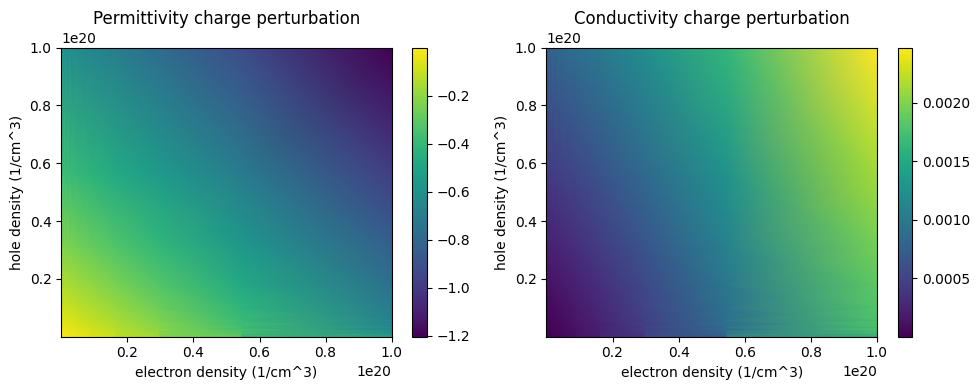

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
permittivity_si_charge.plot(electron_density=Ne_range, hole_density=Nh_range, ax=ax[0])
ax[0].set_title("Permittivity charge perturbation")
conductivity_si_charge.plot(electron_density=Ne_range, hole_density=Nh_range, ax=ax[1])
ax[1].set_title("Conductivity charge perturbation")
plt.tight_layout()
plt.show()

Now that heat and charge specific perturbations for permittivity and condutivity are created, one can pack them into `ParameterPerturbation` instances. Note that since we assume no perturbation to conductivity due to thermal effects, the corresponding `heat` field is not specified.

In [25]:
permittivity_si_perturbation = td.ParameterPerturbation(
    heat=permittivity_si_heat,
    charge=permittivity_si_charge,
)

conductivity_si_perturbation = td.ParameterPerturbation(
    charge=conductivity_si_charge,
)

Finally, a `PerturbationMedium` object can be defined that contains both non-perturbed parameters as well as perturbation models.

In [26]:
si_perturb = td.PerturbationMedium(
    permittivity=permittivity_si,
    conductivity=conductivity_si,
    permittivity_perturbation=permittivity_si_perturbation,
    conductivity_perturbation=conductivity_si_perturbation,
)

### Using in simulations

As mentioned in the introduction, a `PerturbationMedium` can be used as a regular material in constructing a Tidy3D simulation. Once it is finished, a new simualtion with sampled perturbation models can be obtained by using function `Simulation.apply_perturbations(T, Ne, Nh)`.

Let us consider an example of a ring resonator simulation similar to the Ring Resonator example. The following code bellow defines a simulation using created material `si_perturb`. Please refer to Ring Resonator example for details.

In [10]:
# define geometry
wg_width = 0.25
couple_width = 0.05
ring_radius = 3.5
ring_wg_width = 0.25
wg_spacing = 2.0
buffer = 2.0

# compute quantities based on geometry parameters
x_span = 2 * wg_spacing + 2 * ring_radius + 2 * buffer
y_span = 2 * ring_radius + 2 * ring_wg_width + wg_width + couple_width + 2 * buffer
wg_insert_x = ring_radius + wg_spacing
wg_center_y = ring_radius + ring_wg_width / 2.0 + couple_width + wg_width / 2.0

# wavelength range of interest
lambda_beg = 1.5
lambda_end = 1.6

# define pulse parameters
freq_beg = td.C_0 / lambda_end
freq_end = td.C_0 / lambda_beg
# freq0 = (freq_beg + freq_end) / 2
fwidth = (freq_end - freq0) / 1.5

min_steps_per_wvl = 40
run_time = 1e-11

n_bg = 1.46
background = td.Medium(permittivity=n_bg**2)
solid = si_perturb

# background of entire domain (set explicitly as a box)
background_box = td.Structure(
    geometry=td.Box(
        center=[0, 0, 0],
        size=[td.inf, td.inf, td.inf],
    ),
    medium=background,
    name="background",
)

# waveguide
waveguide_top = td.Structure(
    geometry=td.Box(
        center=[0, wg_center_y, 0],
        size=[td.inf, wg_width, td.inf],
    ),
    medium=solid,
    name="waveguide",
)

# waveguide
waveguide_bottom = td.Structure(
    geometry=td.Box(
        center=[0, -wg_center_y, 0],
        size=[td.inf, wg_width, td.inf],
    ),
    medium=solid,
    name="waveguide2",
)

# outside ring
outer_ring = td.Structure(
    geometry=td.Cylinder(
        center=[0, 0, 0],
        axis=2,
        radius=ring_radius + ring_wg_width / 2.0,
        length=td.inf,
    ),
    medium=solid,
    name="outer_ring",
)

# inside ring fill
inner_ring = td.Structure(
    geometry=td.Cylinder(
        center=[0, 0, 0],
        axis=2,
        radius=ring_radius - ring_wg_width / 2.0,
        length=td.inf,
    ),
    medium=background,
    name="inner_ring",
)

mode_plane = td.Box(
    center=[-wg_insert_x, wg_center_y, 0],
    size=[0, 2, td.inf],
)
mode_source = td.ModeSource(
    size=mode_plane.size,
    center=mode_plane.center,
    source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
    mode_spec=td.ModeSpec(num_modes=2),
    mode_index=1,
    direction="+",
    num_freqs=11,  # using 11 (Chebyshev) points to approximate frequency dependence
)

# monitor steady state fields at central frequency over whole domain
field_monitor = td.FieldMonitor(
    center=[0, 0, 0], size=[td.inf, td.inf, 0], freqs=[freq0], name="field"
)


# monitor the mode amps on the output waveguide
lambdas_measure = np.linspace(lambda_beg, lambda_end, 151)
freqs_measure = td.C_0 / lambdas_measure[::-1]

mode_monitor = td.ModeMonitor(
    size=mode_plane.size,
    center=mode_plane.center,
    freqs=freqs_measure,
    mode_spec=td.ModeSpec(num_modes=2),
    name="mode",
)

# lets reset the center to the on the right hand side of the simulation though
mode_monitor = mode_monitor.copy(update=dict(center=[+wg_insert_x, wg_center_y, 0]))

In [11]:
# create simulation
sim = td.Simulation(
    size=[x_span, y_span, 0],
    grid_spec=td.GridSpec.auto(
        min_steps_per_wvl=min_steps_per_wvl, wavelength=td.C_0 / freq0
    ),
    structures=[background_box, outer_ring, inner_ring, waveguide_top, waveguide_bottom],
    sources=[mode_source],
    monitors=[field_monitor, mode_monitor],
    run_time=run_time,
    boundary_spec=td.BoundarySpec(
        x=td.Boundary.pml(), y=td.Boundary.pml(), z=td.Boundary.periodic()
    ),
    shutoff=1e-9,
)


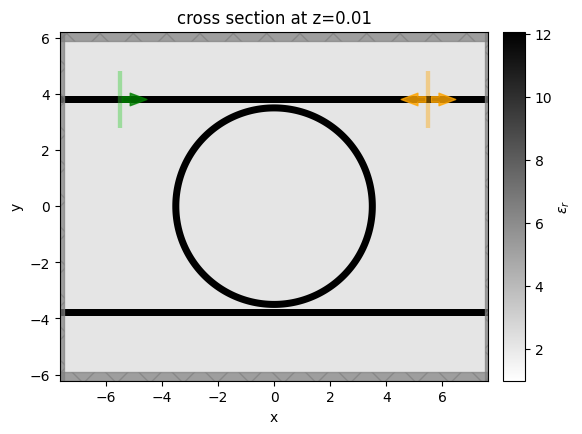

In [12]:
# plot the two simulations
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
sim.plot_eps(z=0.01, ax=ax, freq=freq0)
# sim.plot_grid(z=0.01, ax=ax)
plt.show()

Now let us create fake heat and charge data to use as perturbation data. For temperature field data, we mimic placing of heating element on the inside of the ring structure, such that the peak temperature is 500 K. For charge data, we mimic np-type waveguide.

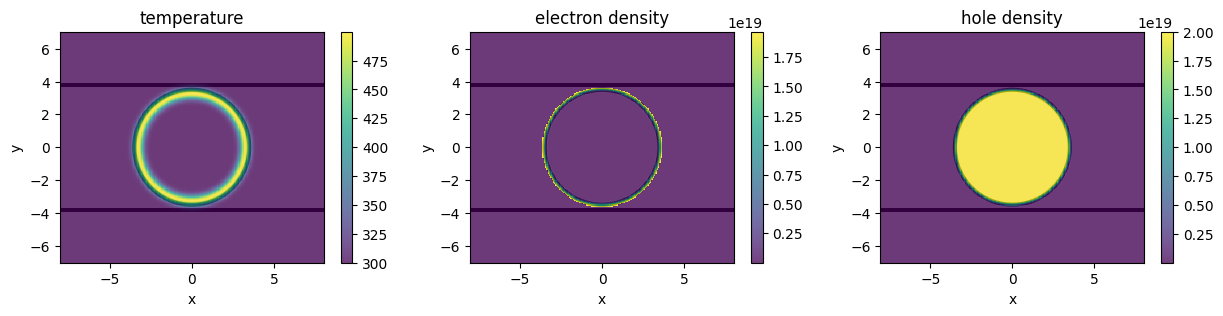

In [32]:
from scipy.special import erf
nx = 201
ny = 202
nz = 2
x = np.linspace(-8,8,nx)
y = np.linspace(-7,7,ny)
z = np.linspace(-1,1,nz)

X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

R2 = X ** 2 + Y ** 2

T_data = 300 + 200 * np.exp(-(np.sqrt(R2) - 0.93*ring_radius) ** 2/0.1)
T_field = td.SpatialDataArray(T_data, coords=dict(x=x, y=y, z=z))

Ne_data = 2e15 + 1e19 * (1 + erf((np.sqrt(R2) - ring_radius)/0.1))
Ne_data[R2 > (ring_radius + 0.5 * wg_width + 0.5 * couple_width) ** 2] = 2e15
Ne_field = td.SpatialDataArray(Ne_data, coords=dict(x=x, y=y, z=z))

Nh_data = 2e15 + 1e19 * (1 - erf((np.sqrt(R2) - ring_radius)/0.1))
Nh_field = td.SpatialDataArray(Nh_data, coords=dict(x=x, y=y, z=z))

fig, ax = plt.subplots(1, 3, figsize=(15, 3))
for ind, (F, name) in enumerate(zip([T, Ne_field, Nh_field], ["temperature", "electron density", "hole density"])):
    sim.plot_structures_eps(z=0, cbar=False, ax=ax[ind])
    F.isel(z=0).plot(alpha=0.75, ax=ax[ind], x="x", y="y")
    ax[ind].set_title(name)

Now these data can be easily used as perturbation data in our simulation. We will consider four cases:
- no perturbations
- heat perturbation
- charge perturbation
- heat and charge perturbations

In [33]:
sim_none = sim.apply_perturbations()
sim_heat = sim.apply_perturbations(temperature=T_field)
sim_charge = sim.apply_perturbations(electron_density=Ne_field, hole_density=Nh_field)
sim_both = sim.apply_perturbations(temperature=T_field, electron_density=Ne_field, hole_density=Nh_field)

First, let us analyze influence of applied perturbations on waveguide modes in the ring structure.

In [16]:
from tidy3d.plugins.mode import ModeSolver

mode_plane = td.Box(
    center=[0, ring_radius, 0],
    size=[0, 2, td.inf],
)
num_modes = 3
mode_spec = td.ModeSpec(num_modes=num_modes)
freqs_mode = np.linspace(freq0 - fwidth, freq0 + fwidth, 11)

mode_data = []
for simul in [sim_none, sim_heat, sim_charge, sim_both]:
    mode_solver = ModeSolver(
        simulation=simul, plane=mode_plane, mode_spec=mode_spec, freqs=freqs_mode
    )
    mode_data.append(mode_solver.solve())

[18:23:37] WARNING: Use the remote mode solver with subpixel averaging for better accuracy       ]8;id=968953;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/plugins/mode/mode_solver.py\mode_solver.py]8;;\:]8;id=575802;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/plugins/mode/mode_solver.py#125\125]8;;\
           through 'tidy3d.plugins.mode.web.run(...)'.                                                             

The following code vizualizes changes in mode propagation indices for first three modes due to perturbations. One can note that for this specfic simulation set up and perturbation data, heat and charge effects almost perfectly cancel each other.

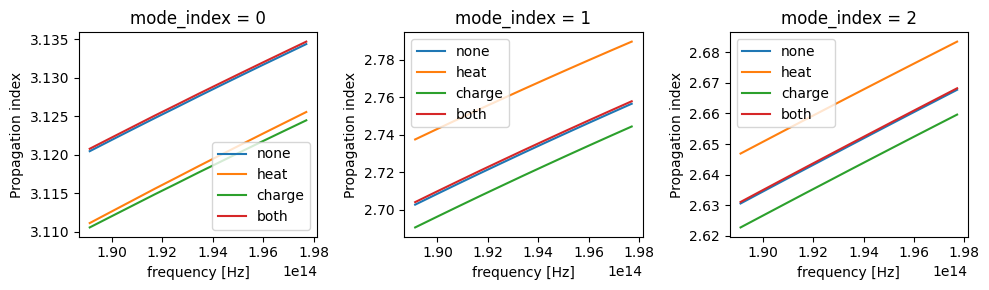

In [34]:
fig, ax = plt.subplots(1, 3, figsize=(10,3))
for ind in range(num_modes):
    for md in mode_data:
        n_eff = md.n_eff 
        n_eff.isel(mode_index=ind).plot.line(x="f", ax=ax[ind])
    ax[ind].legend(["none", "heat", "charge", "both"])

plt.tight_layout()
plt.show()

Now let us submit and run the four simulation set-ups on the servers.

In [35]:
sims = {"sim_none": sim_none, "sim_heat": sim_heat, "sim_charge": sim_charge, "sim_both": sim_both}
batch = web.Batch(simulations=sims, verbose=True)

[18:38:14] Created task 'sim_none' with task_id 'fdve-77afdfa7-6886-4ea2-b32a-4a77d69e74d3v1'.        ]8;id=125174;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py\webapi.py]8;;\:]8;id=87806;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py#186\186]8;;\

           View task using web UI at                                                                  ]8;id=344452;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py\webapi.py]8;;\:]8;id=948956;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py#188\188]8;;\
           ]8;id=572343;https://tidy3d.simulation.cloud/workbench?taskId=fdve-77afdfa7-6886-4ea2-b32a-4a77d69e74d3v1\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=125765;https://tidy3d.simulation.cloud/workbench?taskId=fdve-77afdfa7-6886-4ea2-b32a-4a77d69e74d3v1\taskId]8;;\]8;id=572343;https://tidy3d.simulation.cloud/workbench?taskId=fdve-77afdfa7-6886-4ea2-b32a-4a77d69e74d3v1\=]8;;\]8;id=38081;https://tidy3d.simulation.cloud/workbench?taskId=fdve-77afdfa7-6886-4ea2-b32a-4a77d69e74d3v1\fdve]8;;\]8;id=572343;https://tidy3d.simulation.cloud/workbench?taskId=fdve-77afdfa7-6886-4ea2-b32a-4a77d69e74d3v1\-77afdfa7-6886-4ea2-b32a-4a77d69e74d]8;;\              
           ]8;id=572343;https://tidy3d.simulation.cloud/workbench?taskId=fdve-77afdfa7-6886-4ea2-b32a-4a77d69e74d3v1\3v1']8;;\.                                                                                                   

Output()

[18:38:15] Created task 'sim_heat' with task_id 'fdve-a50d1eff-c6ef-474a-a74b-3b8175c0f7dfv1'.        ]8;id=969108;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py\webapi.py]8;;\:]8;id=91105;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py#186\186]8;;\

           View task using web UI at                                                                  ]8;id=807561;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py\webapi.py]8;;\:]8;id=174947;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py#188\188]8;;\
           ]8;id=429576;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a50d1eff-c6ef-474a-a74b-3b8175c0f7dfv1\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=985247;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a50d1eff-c6ef-474a-a74b-3b8175c0f7dfv1\taskId]8;;\]8;id=429576;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a50d1eff-c6ef-474a-a74b-3b8175c0f7dfv1\=]8;;\]8;id=181136;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a50d1eff-c6ef-474a-a74b-3b8175c0f7dfv1\fdve]8;;\]8;id=429576;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a50d1eff-c6ef-474a-a74b-3b8175c0f7dfv1\-a50d1eff-c6ef-474a-a74b-3b8175c0f7d]8;;\              
           ]8;id=429576;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a50d1eff-c6ef-474a-a74b-3b8175c0f7dfv1\fv1']8;;\.                                                                                                   

...

Output()

[18:38:19] Created task 'sim_both' with task_id 'fdve-9814b1ef-7174-4303-b4c8-cb3c1dbb767ev1'.        ]8;id=748542;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py\webapi.py]8;;\:]8;id=752023;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py#186\186]8;;\

           View task using web UI at                                                                  ]8;id=531036;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py\webapi.py]8;;\:]8;id=476233;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py#188\188]8;;\
           ]8;id=137463;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9814b1ef-7174-4303-b4c8-cb3c1dbb767ev1\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=100858;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9814b1ef-7174-4303-b4c8-cb3c1dbb767ev1\taskId]8;;\]8;id=137463;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9814b1ef-7174-4303-b4c8-cb3c1dbb767ev1\=]8;;\]8;id=33141;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9814b1ef-7174-4303-b4c8-cb3c1dbb767ev1\fdve]8;;\]8;id=137463;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9814b1ef-7174-4303-b4c8-cb3c1dbb767ev1\-9814b1ef-7174-4303-b4c8-cb3c1dbb767]8;;\              
           ]8;id=137463;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9814b1ef-7174-4303-b4c8-cb3c1dbb767ev1\ev1']8;;\.                                                                                                   

Output()

Output()

In [36]:
batch_results = batch.run(path_dir="data_pert")

[18:38:36] Started working on Batch.                                                               ]8;id=903900;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/container.py\container.py]8;;\:]8;id=276707;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/container.py#477\477]8;;\

[18:38:37] Maximum FlexCredit cost: 0.236 for the whole batch. Use 'Batch.real_cost()' to get the  ]8;id=645644;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/container.py\container.py]8;;\:]8;id=13843;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/container.py#481\481]8;;\
           billed FlexCredit cost after the Batch has completed.                                                   

Output()

[18:40:23] Batch complete.                                                                         ]8;id=469438;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/container.py\container.py]8;;\:]8;id=848919;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/container.py#525\525]8;;\

Let us analyze transmission into the fundamental TE mode of the top waveguide.

In [38]:
transmission_amps = {}
for sim_name, sim_data in batch_results.items():
    transmission_amps[sim_name] = sim_data["mode"].amps.sel(mode_index=1, direction="+")

Output()

[18:41:19] loading SimulationData from data_pert/fdve-77afdfa7-6886-4ea2-b32a-4a77d69e74d3v1.hdf5     ]8;id=137728;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py\webapi.py]8;;\:]8;id=741636;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py#602\602]8;;\

Output()

[18:41:44] loading SimulationData from data_pert/fdve-a50d1eff-c6ef-474a-a74b-3b8175c0f7dfv1.hdf5     ]8;id=529110;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py\webapi.py]8;;\:]8;id=654113;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py#602\602]8;;\

Output()

[18:41:50] loading SimulationData from data_pert/fdve-9897de1b-7d42-4aa9-9db8-d0dbc3095303v1.hdf5     ]8;id=878352;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py\webapi.py]8;;\:]8;id=803006;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py#602\602]8;;\

Output()

[18:41:57] loading SimulationData from data_pert/fdve-9814b1ef-7174-4303-b4c8-cb3c1dbb767ev1.hdf5     ]8;id=287362;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py\webapi.py]8;;\:]8;id=667716;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py#602\602]8;;\

As expected, perturbations to waveguide modes in the ring structure result in shifting of transmission curves. Again, note that for this particular simulation set-up heat and charge effects seem to cancel each other.

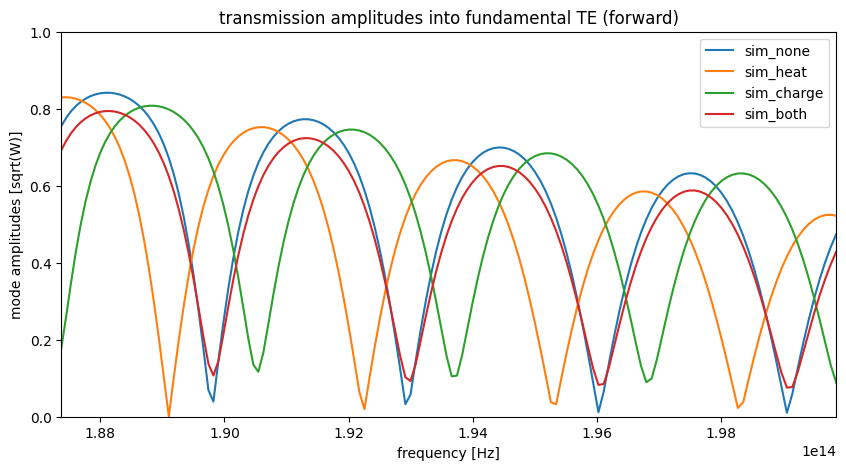

In [39]:
f, ax = plt.subplots(figsize=(10, 5))
for sim_name, amps in transmission_amps.items():
    amps.abs.plot.line(x="f", ax=ax, label=sim_name)
ax.legend()
ax.set_title("transmission amplitudes into fundamental TE (forward)")
ax.set_ylim(0, 1)
ax.set_xlim(freqs_measure[0], freqs_measure[-1])
# ax.set_yscale("log")
plt.show()

## Perturbations of dispersive materials

Non-dispersive material models are best suited for narrow-band simulations. Sometimes it is necessary to use dispersive material models to calculate broadband response more accurately. Similarly to non-dispersive materials, it is easy to create dispersive materials with perturbations. To accomplish that one needs to find the dependence of dispersive model parameters on electron and hole density values. Specifically, we will fit a PoleResiue model with one pole to Si data from previous section over wavelength range $[1.3; 2.0]$ $\mu$m.

### Creation of materials with perturbation information

In [40]:
si = td.material_library['cSi']['Li1993_293K']
n0, k0 = si.nk_model(frequency=td.C_0/np.array(wvl_si_data))
eps0 = si.eps_model(frequency=td.C_0/np.array(wvl_si_data))

First, we create an auxiliary function that creates a dispersion fitter based on experimental $n(\lambda)$ and $k(\lambda)$ data for a specific values of electron and hole densities values.

In [41]:
from tidy3d.plugins.dispersion import DispersionFitter

def create_fitter(Ne, Nh):

    dn = ne_coeff * Ne ** ne_pow + nh_coeff * Nh ** nh_pow
    dk = ke_coeff * Ne ** ke_pow + kh_coeff * Nh ** kh_pow
    
    n_to_fit = n0 + dn
    k_to_fit = k0 + dk
    
    return DispersionFitter(wvl_um=wvl_si_data, n_data=n_to_fit, k_data=k_to_fit)
 

Then we fit PoleResidue parameters to a single point from previously defined electron and hole density ranges `Ne_range` and `Nh_range`.

In [42]:
num_poles = 1

i0 = 10
j0 = 10

Ne = Ne_range[i0]
Nh = Nh_range[j0]

fitter = create_fitter(Ne, Nh)
    
medium, rms_error = fitter.fit(num_poles=num_poles, tolerance_rms=1e-10, num_tries=100)

Output()

[18:43:06] WARNING: Unable to fit with RMS error under 'tolerance_rms' of 1e-10                          ]8;id=703183;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/plugins/dispersion/fit.py\fit.py]8;;\:]8;id=878100;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/plugins/dispersion/fit.py#313\313]8;;\

After that we fit the rest of points in ranges `Ne_range` and `Nh_range`, but this time using neighboring already fitted cases as initial guesses so that the recovered dependencies of pole parameters on electron and hole densities are smooth.

In [43]:
ni = len(Ne_range)
nj = len(Nh_range)

# array to track visited points, fitting error, and resulting fitted mediums
visited = np.zeros((ni, nj))
rms_value = np.zeros((ni, nj))
mediums = np.ndarray((ni, nj), dtype=td.PoleResidue)

# add the point which has already been fitted
visited[i0, j0] = 1
mediums[i0, j0] = medium
rms_value[i0, j0] = rms_error

# calculate "distance" from the strarting point to every other point
# and sort them according to it
dist = ((np.arange(ni) - i0) ** 2)[:, None] + ((np.arange(nj) - j0) ** 2)[None, :]
ind = np.unravel_index(np.argsort(dist, axis=None), dist.shape)

# now loop through all (Ne, Nh) points and fit a medium using
# already fitted neighboring points as initial guess
for i, j in zip(ind[0][1:], ind[1][1:]):
    # create a guess for pole values by averaging already fitted neighboring points
    imin = max(i - 1, 0)
    jmin = max(j - 1, 0)
    imax = min(i + 2, ni)
    jmax = min(j + 2, nj)

    count = 0
    poles = 0
    for ii in range(imin, imax):
        for jj in range(jmin, jmax):
            if visited[ii, jj] == 1 and dist[i][j] > dist[ii][jj]:
                poles += np.array(mediums[ii, jj].poles)
                count += 1
                
    poles /= count

    # create fitter
    Ne = Ne_range[i]
    Nh = Nh_range[j]
    fitter = create_fitter(Ne, Nh)

    # run a single optimization to converge to the nearest optimal point
    guess = fitter._poles_to_coeffs(poles)
    medium_next, rms = fitter._fit_single(num_poles=num_poles, guess=guess)

    # record fitting info
    rms_value[i, j] = rms
    mediums[i, j] = medium_next
    visited[i, j] = 1

We can visulize the resulting fitting errors to confirm that fitting procedure was successful for every (Ne, Nh) data point.

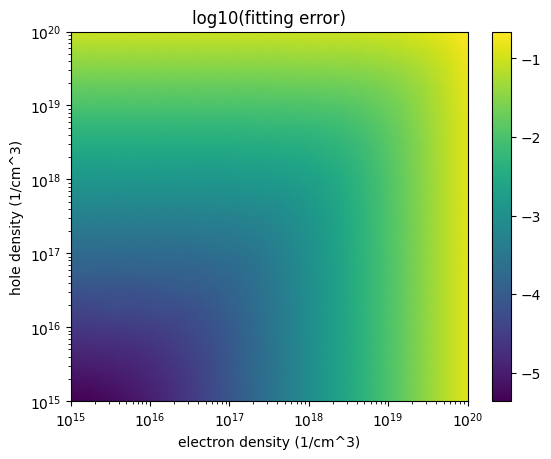

In [44]:
pc = plt.pcolormesh(Ne_mesh, Nh_mesh, np.log10(rms_value), shading="gouraud")
plt.colorbar(pc)
plt.title("log10(fitting error)")
plt.xlabel("electron density (1/cm^3)")
plt.ylabel("hole density (1/cm^3)")
plt.xscale("log")
plt.yscale("log")
plt.show()

Now we pack fitted pole parameters into `ParameterPerturbation` objects.

In [45]:
da_data = td.ChargeDataArray([[m.poles[0][0] - si.poles[0][0] for m in mediums[Ne_ind]] for Ne_ind in range(ni)], coords=dict(n=Ne_range, p=Nh_range))
dc_data = td.ChargeDataArray([[m.poles[0][1] - si.poles[0][1] for m in mediums[Ne_ind]] for Ne_ind in range(ni)], coords=dict(n=Ne_range, p=Nh_range))

a_si_perturbation = td.ParameterPerturbation(
    charge=td.CustomChargePerturbation(perturbation_values=da_data),
)

c_si_perturbation = td.ParameterPerturbation(
    charge=td.CustomChargePerturbation(perturbation_values=dc_data),
)

Visualization of pole parameters perturbations.

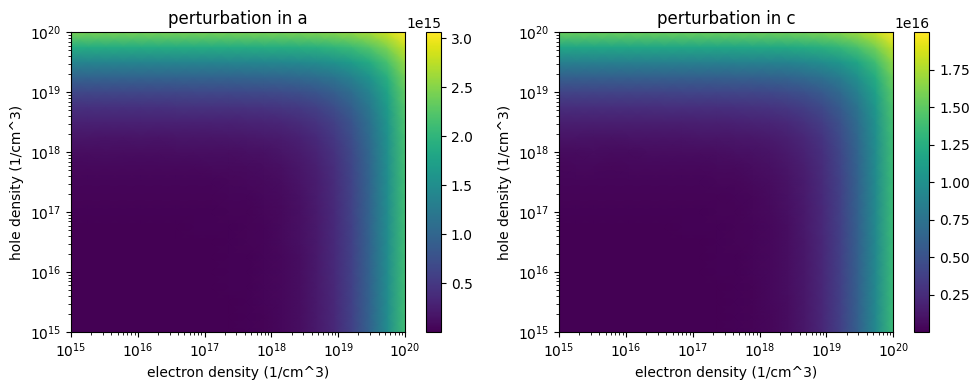

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

a_si_perturbation.charge.plot(electron_density=Ne_range, hole_density=Nh_range, ax=ax[0], val='abs')
ax[0].set_title("perturbation in a")
ax[0].set_xscale("log")
ax[0].set_yscale("log")

c_si_perturbation.charge.plot(electron_density=Ne_range, hole_density=Nh_range, ax=ax[1], val='abs')
ax[1].set_title("perturbation in c")
ax[1].set_xscale("log")
ax[1].set_yscale("log")

plt.tight_layout()
plt.show()

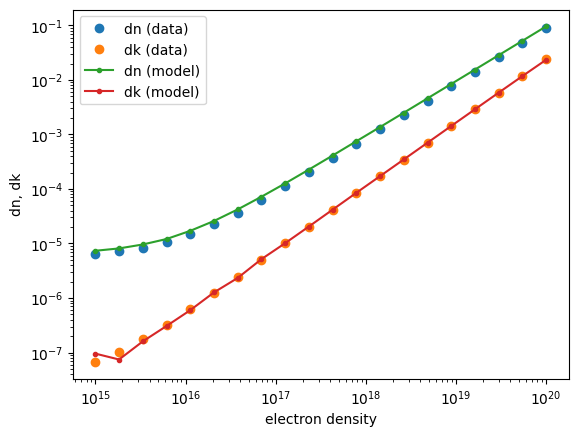

In [51]:
wvl_ind = 1

Nh_ind = 0

dn_data = ne_coeff[wvl_ind] * Ne_range ** ne_pow[wvl_ind] + nh_coeff[wvl_ind] * Nh_range[Nh_ind] ** nh_pow[wvl_ind]
dk_data = ke_coeff[wvl_ind] * Ne_range ** ke_pow[wvl_ind] + kh_coeff[wvl_ind] * Nh_range[Nh_ind] ** kh_pow[wvl_ind]

dn_model = []
dk_model = []
for med in mediums[:, Nh_ind]:
    n, k = med.nk_model(td.C_0/wvl_si_data[wvl_ind])
    dn_model.append(n-n0[wvl_ind])
    dk_model.append(k-k0[wvl_ind])

plt.loglog(Ne_range, np.abs(dn_data), 'o', label="dn (data)")
plt.loglog(Ne_range, np.abs(dk_data), 'o', label="dk (data)")
plt.loglog(Ne_range, np.abs(dn_model), '.-', label="dn (model)")
plt.loglog(Ne_range, np.abs(dk_model), '.-', label="dk (model)")

plt.xlabel("electron density")
plt.ylabel("dn, dk")

plt.legend()

plt.show()

A `PoleResiude` dispersive medium with perturbations can be created as follows.

In [52]:
si_disp_perturb = td.PerturbationPoleResidue(
    eps_inf=si.eps_inf,
    poles=si.poles,
    eps_inf_perturbation=td.ParameterPerturbation(),
    poles_perturbation=[(a_si_perturbation, c_si_perturbation)],
)

We repeat the simulation run from previous section but substituting non-dispersive medium of the ring structure with the just created dispersive one.

In [53]:
# outside ring
outer_ring_disp = td.Structure(
    geometry=td.Cylinder(
        center=[0, 0, 0],
        axis=2,
        radius=ring_radius + ring_wg_width / 2.0,
        length=td.inf,
    ),
    medium=si_disp_perturb,
    name="outer_ring",
)

sim_disp = td.Simulation(
    size=[x_span, y_span, 0],
    grid_spec=td.GridSpec.auto(
        min_steps_per_wvl=min_steps_per_wvl, wavelength=td.C_0 / freq0
    ),
    structures=[background_box, outer_ring_disp, inner_ring, waveguide_top, waveguide_bottom],
    sources=[mode_source],
    monitors=[field_monitor, mode_monitor],
    run_time=run_time,
    boundary_spec=td.BoundarySpec(
        x=td.Boundary.pml(), y=td.Boundary.pml(), z=td.Boundary.periodic()
    ),
    shutoff=1e-9,
    subpixel=False
)

Using the `apply_perturbations` function to take into account charge data.

In [55]:
sim_charge_disp = sim_disp.apply_perturbations(electron_density=Ne_field, hole_density=Nh_field)

We will compare the results to a simulation run based on using non-dispersive medium.

In [56]:
sim_charge_nondisp = sim_charge.updated_copy(subpixel=False)

First we compare waveguide mode propagation indices.

In [57]:
mode_plane = td.Box(
    center=[0, ring_radius, 0],
    size=[0, 2, td.inf],
)
num_modes = 3
mode_spec = td.ModeSpec(num_modes=num_modes)
freqs_mode = np.linspace(freq0 - 3*fwidth, freq0 + 3*fwidth, 11)

mode_data = []
for simul in [sim_charge_nondisp, sim_charge_disp]:
    mode_solver = ModeSolver(
        simulation=simul, plane=mode_plane, mode_spec=mode_spec, freqs=freqs_mode
    )
    mode_data.append(mode_solver.solve())

As one expects, the two cases coincide only in one frequency point. (Note that this frequency point is expected to be the central wavelength $\lambda=1.55$ $\mu$m, but because of slight differences in fitting experimental $dn(N_e, N_h)$ and $dk(N_e, N_h)$ data when creating `PerturbationMedium` and `PerturbationPoleResidue`, the coinciding point is slightly shifted)

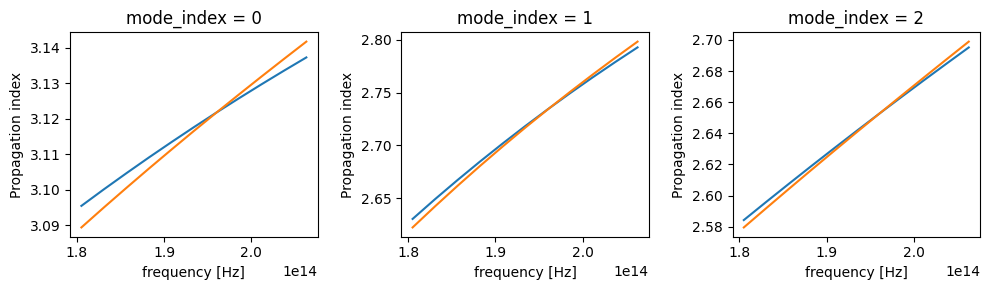

In [58]:
fig, ax = plt.subplots(1, 3, figsize=(10,3))
for ind in range(num_modes):
    for md in mode_data[:4]:
        n_eff = md.n_eff 
        n_eff.isel(mode_index=ind).plot.line(x="f", ax=ax[ind])
    # ax[ind].legend(["none", "heat", "charge", "both"])

plt.tight_layout()
plt.show()

Next we compare full simulation run of the two cases.

In [59]:
sims = {"sim_charge_disp": sim_charge_disp, "sim_charge": sim_charge_nondisp}
batch = web.Batch(simulations=sims, verbose=True)

[18:47:10] Created task 'sim_charge_disp' with task_id 'fdve-b82d7849-f4f1-4658-b96f-4966d58d316av1'. ]8;id=251691;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py\webapi.py]8;;\:]8;id=75021;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py#186\186]8;;\

           View task using web UI at                                                                  ]8;id=602976;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py\webapi.py]8;;\:]8;id=727319;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py#188\188]8;;\
           ]8;id=577639;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b82d7849-f4f1-4658-b96f-4966d58d316av1\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=110805;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b82d7849-f4f1-4658-b96f-4966d58d316av1\taskId]8;;\]8;id=577639;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b82d7849-f4f1-4658-b96f-4966d58d316av1\=]8;;\]8;id=520513;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b82d7849-f4f1-4658-b96f-4966d58d316av1\fdve]8;;\]8;id=577639;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b82d7849-f4f1-4658-b96f-4966d58d316av1\-b82d7849-f4f1-4658-b96f-4966d58d316]8;;\              
           ]8;id=577639;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b82d7849-f4f1-4658-b96f-4966d58d316av1\av1']8;;\.                                                                                                   

Output()

Output()

[18:47:12] Created task 'sim_charge' with task_id 'fdve-40ac6e14-4b72-4540-9fc5-eec636d54f96v1'.      ]8;id=912784;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py\webapi.py]8;;\:]8;id=506883;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py#186\186]8;;\

           View task using web UI at                                                                  ]8;id=394785;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py\webapi.py]8;;\:]8;id=386029;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py#188\188]8;;\
           ]8;id=918847;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40ac6e14-4b72-4540-9fc5-eec636d54f96v1\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=730463;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40ac6e14-4b72-4540-9fc5-eec636d54f96v1\taskId]8;;\]8;id=918847;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40ac6e14-4b72-4540-9fc5-eec636d54f96v1\=]8;;\]8;id=284636;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40ac6e14-4b72-4540-9fc5-eec636d54f96v1\fdve]8;;\]8;id=918847;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40ac6e14-4b72-4540-9fc5-eec636d54f96v1\-40ac6e14-4b72-4540-9fc5-eec636d54f9]8;;\              
           ]8;id=918847;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40ac6e14-4b72-4540-9fc5-eec636d54f96v1\6v1']8;;\.                                                                                                   

Output()

Output()

In [60]:
batch_results = batch.run(path_dir="data_pert")

[18:47:17] Started working on Batch.                                                               ]8;id=241269;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/container.py\container.py]8;;\:]8;id=951424;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/container.py#477\477]8;;\

[18:47:18] Maximum FlexCredit cost: 0.050 for the whole batch. Use 'Batch.real_cost()' to get the  ]8;id=921295;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/container.py\container.py]8;;\:]8;id=115125;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/container.py#481\481]8;;\
           billed FlexCredit cost after the Batch has completed.                                                   

Output()

[18:48:53] Batch complete.                                                                         ]8;id=563286;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/container.py\container.py]8;;\:]8;id=897190;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/container.py#525\525]8;;\

In [61]:
transmission_amps = {}
for sim_name, sim_data in batch_results.items():
    transmission_amps[sim_name] = sim_data["mode"].amps.sel(mode_index=1, direction="+")

Output()

[18:49:01] loading SimulationData from data_pert/fdve-b82d7849-f4f1-4658-b96f-4966d58d316av1.hdf5     ]8;id=997396;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py\webapi.py]8;;\:]8;id=869929;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py#602\602]8;;\

Output()

[18:49:10] loading SimulationData from data_pert/fdve-40ac6e14-4b72-4540-9fc5-eec636d54f96v1.hdf5     ]8;id=272674;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py\webapi.py]8;;\:]8;id=283422;file:///home/daniil/Flexcompute/Code/core/active/tidy3d_frontend/tidy3d/web/webapi.py#602\602]8;;\

We see again that the two simulation coincide in a single frequency point, but differ away from it due to additional frequency dependence of dispersive material model.

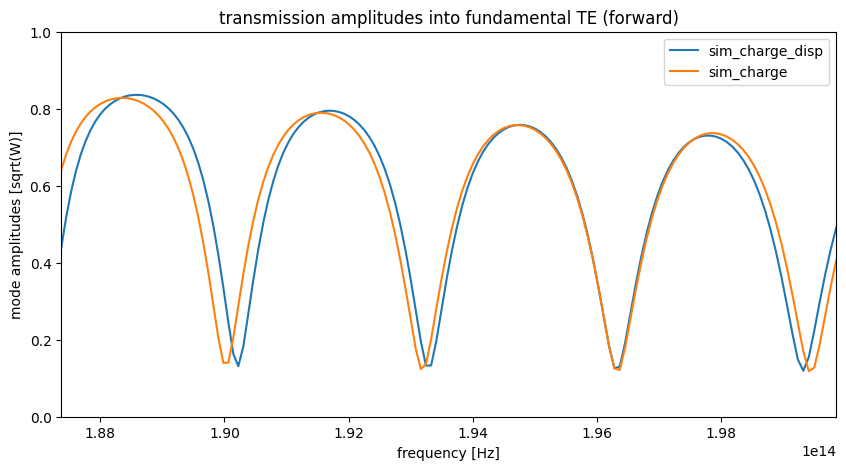

In [62]:
f, ax = plt.subplots(figsize=(10, 5))
for sim_name, amps in transmission_amps.items():
    amps.abs.plot.line(x="f", ax=ax, label=sim_name)
ax.legend()
ax.set_title("transmission amplitudes into fundamental TE (forward)")
ax.set_ylim(0, 1)
ax.set_xlim(freqs_measure[0], freqs_measure[-1])
# ax.set_yscale("log")
plt.show()